=========================================================
### FASE 2 - MODELADO Y SEGMENTACIÓN
### TFM - ANALÍTICA Y VISUALIZACIÓN DE DATOS MASIVOS
=========================================================

In [1]:
# =========================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =========================================================

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('ggplot')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    silhouette_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#Metricas
from sklearn.linear_model import LogisticRegression

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


### Cargar datasets resultantes del EDA

In [2]:
# =========================================================
# 2. CARGA DE DATASETS
# =========================================================

dataset_alertas = pd.read_csv(
    'dataset_alertas.csv'
)

dataset_t4 = pd.read_csv(
    'dataset_t4.csv'
)

print('Datasets cargados correctamente')

Datasets cargados correctamente


In [3]:
# =========================================================
# 3. VALIDACIÓN DATASETS
# =========================================================

print('\n=========== DATASET ALERTAS ===========')
print(dataset_alertas.shape)

print('\n=========== DATASET T4 ===========')
print(dataset_t4.shape)


=========== DATASET ALERTAS ===========
(43058, 12)

=========== DATASET T4 ===========
(25488, 23)


In [4]:
# =========================================================
# 4. COLUMNAS DATASET ALERTAS
# =========================================================

print(dataset_alertas.columns)

Index(['ANNO', 'TRIMESTRE', 'DANE', 'NOMBRE ESTABLECIMIENTO', 'TIPO',
       'TIPO_ALERTA', 'PRESP_DEFINITIVO', 'PAGOS', 'RECAUDO', 'IND_EJECUCION',
       'IND_COMPROMISO', 'VAR_EJECUCION'],
      dtype='str')


### 1. Modelo supervisado - RANDOM FOREST

In [5]:
# =========================================================
# 5. PREPARACIÓN DATASET MODELO SUPERVISADO
# =========================================================

df_model = dataset_alertas.copy()

# ---------------------------------------------------------
# Verificar clases
# ---------------------------------------------------------

print(df_model['TIPO_ALERTA'].value_counts())

# =========================================================
# VARIABLES PREDICTORAS
# =========================================================

features = [
    'PRESP_DEFINITIVO',
    'PAGOS',
    'IND_COMPROMISO',
    'VAR_EJECUCION',
    'ANNO',
    'TRIMESTRE'
]

X = df_model[features]

# =========================================================
# VARIABLE OBJETIVO
# =========================================================

y = df_model['TIPO_ALERTA']

TIPO_ALERTA
ESTANCAMIENTO     20366
REVERSION         15537
BAJA_EJECUCION     3589
ACELERACION        2618
ALTA_EJECUCION      948
Name: count, dtype: int64


In [6]:
# =========================================================
# 6. TRAIN TEST SPLIT
# =========================================================
# División entrenamiento/prueba
# Usaremos: 70% entrenamiento y 30% prueba


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print('\nTrain:')
print(X_train.shape)

print('\nTest:')
print(X_test.shape)


Train:
(30140, 6)

Test:
(12918, 6)


In [7]:
print(y_train.value_counts())

print('\n--------------------------\n')

print(y_test.value_counts())

TIPO_ALERTA
ESTANCAMIENTO     14256
REVERSION         10876
BAJA_EJECUCION     2512
ACELERACION        1832
ALTA_EJECUCION      664
Name: count, dtype: int64

--------------------------

TIPO_ALERTA
ESTANCAMIENTO     6110
REVERSION         4661
BAJA_EJECUCION    1077
ACELERACION        786
ALTA_EJECUCION     284
Name: count, dtype: int64


In [8]:
# =========================================================
# 7. RANDOM FOREST CLASSIFIER
# =========================================================

# Entrenamiento Random Forest

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

# ---------------------------------------------------------
# Entrenamiento
# ---------------------------------------------------------

model.fit(X_train, y_train)

print('Modelo entrenado correctamente')

Modelo entrenado correctamente


In [9]:
# =========================================================
# IMPORTANCIA VARIABLES
# =========================================================

importance = pd.DataFrame({
    'Variable': features,
    'Importancia': model.feature_importances_
})

importance = importance.sort_values(
    by='Importancia',
    ascending=False
)

print(importance)

           Variable  Importancia
3     VAR_EJECUCION     0.450401
5         TRIMESTRE     0.264747
2    IND_COMPROMISO     0.176112
1             PAGOS     0.076252
0  PRESP_DEFINITIVO     0.022626
4              ANNO     0.009862


In [10]:
# =========================================================
# 8. PREDICCIONES
# =========================================================

y_pred_model1 = model.predict(X_test)
y_test_model1 = y_test.copy()
print(y_pred_model1[:10])


['BAJA_EJECUCION' 'REVERSION' 'BAJA_EJECUCION' 'ALTA_EJECUCION'
 'ESTANCAMIENTO' 'ESTANCAMIENTO' 'REVERSION' 'REVERSION' 'ACELERACION'
 'ESTANCAMIENTO']


In [26]:
# =========================================================
# 9. MÉTRICAS DEL MODELO
# =========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ---------------------------------------------------------
# Accuracy
# ---------------------------------------------------------

accuracy_model1 = accuracy_score(y_test_model1, y_pred_model1)

print('\n=========== ACCURACY ===========')
print(accuracy_model1)


# ---------------------------------------------------------
# F1
# ---------------------------------------------------------
report_model1 = classification_report(
    y_test_model1,
    y_pred_model1,
    output_dict=True
)

f1_rf = report_model1['weighted avg']['f1-score']
print('\n=========== F1-score RF ===========')
print(f1_rf)

# ---------------------------------------------------------
# Classification Report
# ---------------------------------------------------------

print('\n=========== CLASSIFICATION REPORT ===========')

print(classification_report(y_test_model1, y_pred_model1))



# ---------------------------------------------------------
# Matriz de Confusión
# ---------------------------------------------------------

matriz_model1 = confusion_matrix(y_test_model1, y_pred_model1)

print('\n=========== MATRIZ DE CONFUSIÓN ===========')

print(matriz_model1)


=========== ACCURACY ===========
0.918408422356402

=========== F1-score RF ===========
0.9267021688323195

=========== CLASSIFICATION REPORT ===========
                precision    recall  f1-score   support

   ACELERACION       0.97      0.88      0.92       786
ALTA_EJECUCION       0.65      0.89      0.75       284
BAJA_EJECUCION       0.55      0.97      0.70      1077
 ESTANCAMIENTO       1.00      0.96      0.98      6110
     REVERSION       0.99      0.86      0.92      4661

      accuracy                           0.92     12918
     macro avg       0.83      0.91      0.86     12918
  weighted avg       0.95      0.92      0.93     12918


=========== MATRIZ DE CONFUSIÓN ===========
[[ 692   94    0    0    0]
 [  23  252    1    4    4]
 [   0    4 1045    4   24]
 [   0   28  217 5865    0]
 [   0    8  643    0 4010]]


In [12]:
# =========================================================
# 10. COMPARACIÓN DE ALGORITMOS SUPERVISADOS
# =========================================================

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

# =========================================
# TRATAMIENTO DE NULOS
# =========================================

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)


In [13]:
# =========================================
# IMPLEMENTACIÓN DE LOGISTIC REGRESSION
# =========================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score


lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_lr, y_train)

y_pred_lr = lr.predict(X_test_lr)


# =========================================
# EVALUACIÓN DEL MODELO
# =========================================

accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)


# =========================================
# RESULTADOS
# =========================================

print("Accuracy:", accuracy_lr)

print("F1-score:", f1_lr)

Accuracy: 0.8549311038860504
F1-score: 0.8516021490522622


In [ ]:
# =========================================
# IMPLEMENTACIÓN DE DECISIONTREECLASSIFIER
# =========================================
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

print("Accuracy DT:", accuracy_dt)
print("F1-score DT:", f1_dt)

Accuracy DT: 0.8696392630438148
F1-score DT: 0.8727163429851069


In [22]:
# =========================================
# SVM (SVC ORIGINAL)
# =========================================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

svm = SVC(
    kernel='linear',
    max_iter=10000
)

svm.fit(X_train_lr, y_train)

y_pred_svm = svm.predict(X_test_lr)

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

print("Accuracy SVM:", accuracy_svm)
print("F1-score SVM:", f1_svm)

Accuracy SVM: 0.8808639108221087
F1-score SVM: 0.870461944520621


In [27]:
resultados = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Decision Tree',
        'SVM',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_dt,
        accuracy_svm,
        accuracy_model1
    ],
    'F1-Score': [
        f1_lr,
        f1_dt,
        f1_svm,
        f1_rf
    ]
})

resultados

,Modelo,Accuracy,F1-Score
0,Logistic Regression,0.854931,0.851602
1,Decision Tree,0.869639,0.872716
2,SVM,0.880864,0.870462
3,Random Forest,0.918408,0.926702


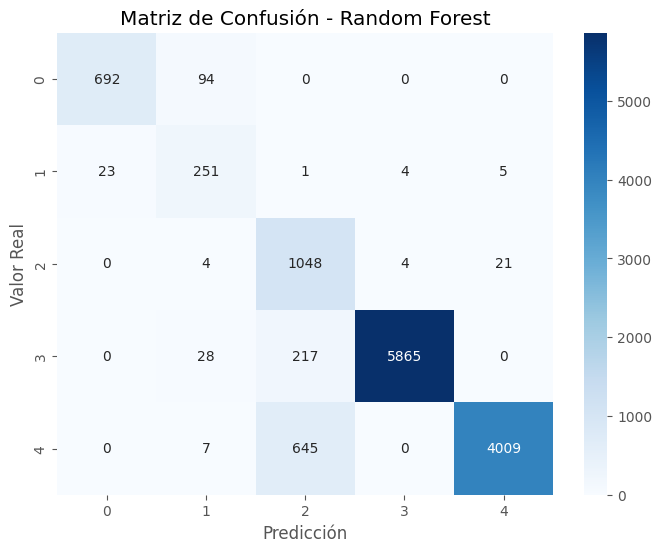

In [ ]:
# =========================================================
# 11. MATRIZ DE CONFUSIÓN
# =========================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    matriz_model1,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - Random Forest')

plt.xlabel('Predicción')

plt.ylabel('Valor Real')

plt.show()

In [ ]:
# =========================================================
# 12. IMPORTANCIA VARIABLES
# =========================================================

importance = pd.DataFrame({
    'Variable': features,
    'Importancia': model.feature_importances_
})

importance = importance.sort_values(
    by='Importancia',
    ascending=False
)

print(importance)

           Variable  Importancia
3     VAR_EJECUCION     0.450631
5         TRIMESTRE     0.263987
2    IND_COMPROMISO     0.178112
1             PAGOS     0.075353
0  PRESP_DEFINITIVO     0.022402
4              ANNO     0.009515


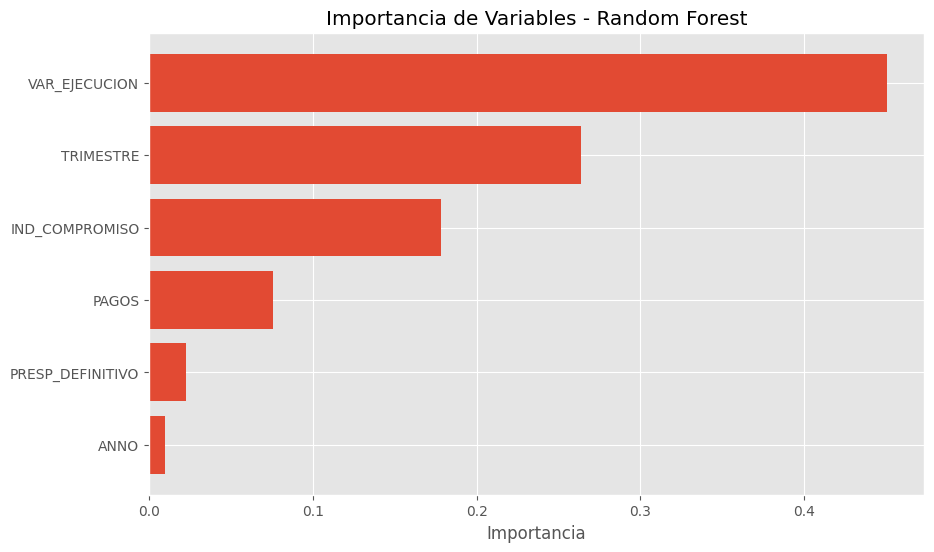

In [ ]:
# =========================================================
# 13. GRÁFICA IMPORTANCIA VARIABLES
# =========================================================

plt.figure(figsize=(10,6))

plt.barh(
    importance['Variable'],
    importance['Importancia']
)

plt.gca().invert_yaxis()
plt.title('Importancia de Variables - Random Forest')
plt.xlabel('Importancia')
plt.show()

In [ ]:
# =========================================================
# 14. DATASET DE PREDICCIONES RANDOM FOREST
# =========================================================

# ---------------------------------------------------------
# Copia del dataset original
# ---------------------------------------------------------
df_predicciones = df_model.copy()

# ---------------------------------------------------------
# Predicción del tipo de alerta
# ---------------------------------------------------------
df_predicciones['TIPO_ALERTA_PREDICHA'] = model.predict(X)

# ---------------------------------------------------------
# Probabilidad máxima de predicción
# ---------------------------------------------------------
probabilidades = model.predict_proba(X)

df_predicciones['PROBABILIDAD'] = (
    probabilidades.max(axis=1)
)

# ---------------------------------------------------------
# Validación
# ---------------------------------------------------------
print(df_predicciones.shape)
print(
    df_predicciones[
        [
            'TIPO_ALERTA',
            'TIPO_ALERTA_PREDICHA',
            'PROBABILIDAD'
        ]
    ].head()
)

(43058, 14)
      TIPO_ALERTA TIPO_ALERTA_PREDICHA  PROBABILIDAD
0  BAJA_EJECUCION       BAJA_EJECUCION      0.517349
1  BAJA_EJECUCION       BAJA_EJECUCION      0.804444
2  BAJA_EJECUCION       BAJA_EJECUCION      0.988727
3  BAJA_EJECUCION       BAJA_EJECUCION      0.817006
4  BAJA_EJECUCION       BAJA_EJECUCION      0.818104


=========================================================
### SEGUNDA SIMULACIÓN RANDOM FOREST
### SIN VAR_EJECUCION
=========================================================

In [16]:
# ---------------------------------------------------------
# Copia dataset
# ---------------------------------------------------------

df_model_2 = dataset_alertas.copy()

# ---------------------------------------------------------
# Eliminar clases con baja frecuencia
# ---------------------------------------------------------
"""df_model_2 = df_model_2[
    df_model_2['TIPO_ALERTA'] != 'BAJA_EJECUCION'
]
"""
# ---------------------------------------------------------
# Variables predictoras
# ---------------------------------------------------------
# Se excluye VAR_EJECUCION para reducir
# posibles efectos de data leakage
# ---------------------------------------------------------

features_2 = [
    'PRESP_DEFINITIVO',
    'PAGOS',
    'RECAUDO',
    'IND_COMPROMISO',
    'ANNO',
    'TRIMESTRE'
]

X = df_model_2[features_2]

# ---------------------------------------------------------
# Variable objetivo
# ---------------------------------------------------------

y = df_model_2['TIPO_ALERTA']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# =========================================================
# RANDOM FOREST
# =========================================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

# ---------------------------------------------------------
# Entrenamiento
# ---------------------------------------------------------

model.fit(X_train, y_train)

# =========================================================
# PREDICCIONES
# =========================================================

y_pred = model.predict(X_test)

# =========================================================
# EVALUACIÓN
# =========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ---------------------------------------------------------
# Accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print('\n=========== ACCURACY ===========')
print(accuracy)

# ---------------------------------------------------------
# Classification Report
# ---------------------------------------------------------

print('\n=========== CLASSIFICATION REPORT ===========')

print(classification_report(y_test, y_pred))

# ---------------------------------------------------------
# Matriz de Confusión
# ---------------------------------------------------------

matriz = confusion_matrix(y_test, y_pred)

print('\n=========== MATRIZ DE CONFUSIÓN ===========')

print(matriz)


=========== ACCURACY ===========
0.6370181142591732

=========== CLASSIFICATION REPORT ===========
                precision    recall  f1-score   support

   ACELERACION       0.29      0.85      0.44       786
ALTA_EJECUCION       0.65      0.93      0.76       284
BAJA_EJECUCION       0.54      0.96      0.69      1077
 ESTANCAMIENTO       0.76      0.59      0.67      6110
     REVERSION       0.74      0.57      0.64      4661

      accuracy                           0.64     12918
     macro avg       0.60      0.78      0.64     12918
  weighted avg       0.70      0.64      0.65     12918


=========== MATRIZ DE CONFUSIÓN ===========
[[ 670   96    3    3   14]
 [  17  263    0    0    4]
 [  24    0 1033    2   18]
 [1330   28  222 3620  910]
 [ 248   20  641 1109 2643]]


### 2. clustering institucional con PCA + KMeans.
### PASO 1 — Preparación dataset clustering

In [17]:
# =========================================================
# 20. DATASET PARA CLUSTERING (NIVEL INSTITUCIÓN)
# =========================================================

df_cluster_anual = (
    dataset_t4
    .groupby(["DANE","ANNO"])
    .agg({
        'PRESP_DEFINITIVO':'mean',
        'COMPROMISOS':'mean',
        'OBLIGACIONES':'mean',
        'PAGOS':'mean',
        'IND_EJECUCION':'mean',
        'IND_COMPROMISO':'mean',
        'VAR_EJECUCION':'mean'
    })
    .reset_index()
)

print(df_cluster_anual.shape)
print(df_cluster_anual.head())

(1315, 9)
           DANE  ANNO  PRESP_DEFINITIVO   COMPROMISOS  OBLIGACIONES  \
0  113006000664  2020      7.484811e+06  6.586940e+06  6.586940e+06   
1  113006000664  2021      5.499575e+06  4.960264e+06  4.960264e+06   
2  113006000664  2022      5.313852e+06  4.844657e+06  4.844657e+06   
3  113006000664  2023      7.004724e+06  6.906974e+06  6.906974e+06   
4  113006000664  2024      1.263233e+07  1.244900e+07  1.244900e+07   

          PAGOS  IND_EJECUCION  IND_COMPROMISO  VAR_EJECUCION  
0  6.586940e+06      52.530000       52.530000   4.529000e+00  
1  4.960264e+06      67.440000       67.440000  -1.539173e-16  
2  4.844657e+06      77.482222       77.482222  -1.250000e+01  
3  6.906974e+06      69.942000       69.942000   9.942000e+00  
4  1.244900e+07      77.011111       77.011111   0.000000e+00  


In [18]:
# =========================================================
# 21. VARIABLES PARA CLUSTERING
# =========================================================

features_cluster = [
    'IND_EJECUCION',
    'IND_COMPROMISO',
    'VAR_EJECUCION'
]

X_cluster = df_cluster_anual[features_cluster]

print(X_cluster.shape)

(1315, 3)


In [19]:
# =========================================================
# 22. VALIDACIÓN NULOS
# =========================================================

print(X_cluster.isnull().sum())

IND_EJECUCION     1
IND_COMPROMISO    1
VAR_EJECUCION     2
dtype: int64


In [20]:
# =========================================================
# 24. IMPUTACIÓN DE NULOS
# =========================================================

# Reemplazar nulos por mediana

X_cluster = X_cluster.fillna(
    X_cluster.median()
)

# ---------------------------------------------------------
# Validar nuevamente
# ---------------------------------------------------------

print(X_cluster.isnull().sum())

IND_EJECUCION     0
IND_COMPROMISO    0
VAR_EJECUCION     0
dtype: int64


In [21]:
# =========================================================
# 23. ESCALAMIENTO VARIABLES
# =========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print(X_scaled.shape)

(1315, 3)


In [22]:
# =========================================================
# 25. PCA - ANÁLISIS COMPONENTES PRINCIPALES
# =========================================================

from sklearn.decomposition import PCA

# ---------------------------------------------------------
# PCA completo
# ---------------------------------------------------------

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(1315, 3)


In [23]:
# =========================================================
# 26. VARIANZA EXPLICADA
# =========================================================

explained_variance = pca.explained_variance_ratio_

print('\n=========== VARIANZA EXPLICADA ===========')

print(explained_variance)


=========== VARIANZA EXPLICADA ===========
[0.62380313 0.32856667 0.04763019]


In [24]:
# =========================================================
# 27. VARIANZA ACUMULADA
# =========================================================

import numpy as np

varianza_acumulada = np.cumsum(
    explained_variance
)

print('\n=========== VARIANZA ACUMULADA ===========')

print(varianza_acumulada)


=========== VARIANZA ACUMULADA ===========
[0.62380313 0.95236981 1.        ]


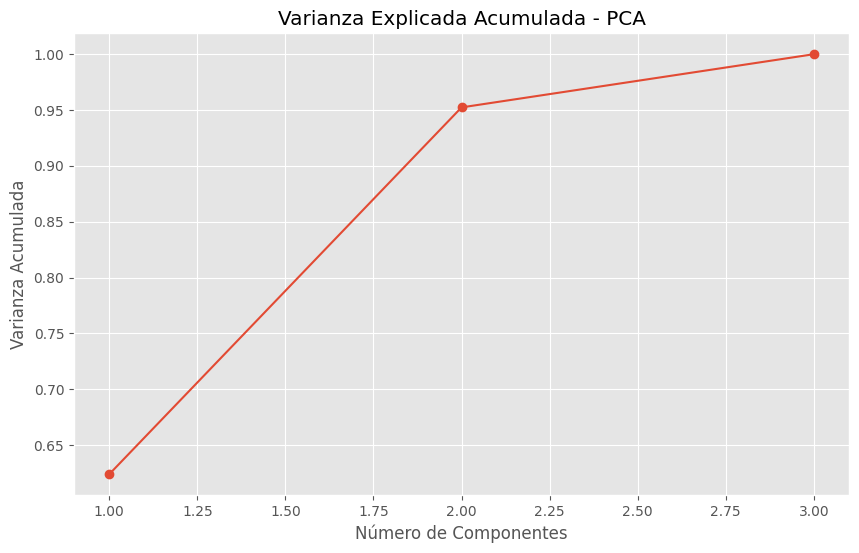

In [25]:
# =========================================================
# 28. GRÁFICA VARIANZA ACUMULADA
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(varianza_acumulada)+1),
    varianza_acumulada,
    marker='o'
)

plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Explicada Acumulada - PCA')
plt.grid(True)
plt.show()

In [26]:
# =========================================================
# 29. PCA FINAL - 3 COMPONENTES
# =========================================================

from sklearn.decomposition import PCA

pca_final = PCA(n_components=3)

X_pca_final = pca_final.fit_transform(
    X_scaled
)

print(X_pca_final.shape)

(1315, 3)


In [27]:
# =========================================================
# 30. DATAFRAME PCA
# =========================================================

df_pca = pd.DataFrame(
    X_pca_final,
    columns=['PC1', 'PC2', 'PC3']
)

print(df_pca.head())

        PC1       PC2       PC3
0 -1.739764  0.409086 -0.131003
1 -0.736985 -0.198024 -0.059438
2 -0.188049 -1.589841  0.000582
3 -0.425494  0.813283 -0.060813
4 -0.054370 -0.285338 -0.017134


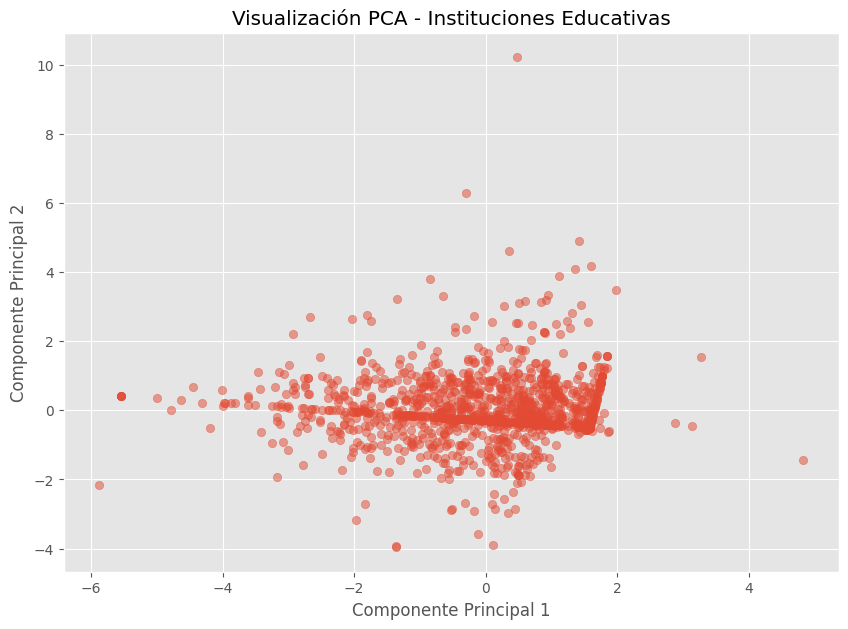

In [28]:
# =========================================================
# 31. VISUALIZACIÓN PCA
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    alpha=0.5
)

plt.title('Visualización PCA - Instituciones Educativas')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

### Paso 2 - número óptimo de clusters.

In [29]:
# =========================================================
# 32. ELBOW METHOD
# =========================================================

from sklearn.cluster import KMeans

inercia = []

# ---------------------------------------------------------
# Probar diferentes valores de K
# ---------------------------------------------------------

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca_final)
    inercia.append(kmeans.inertia_)

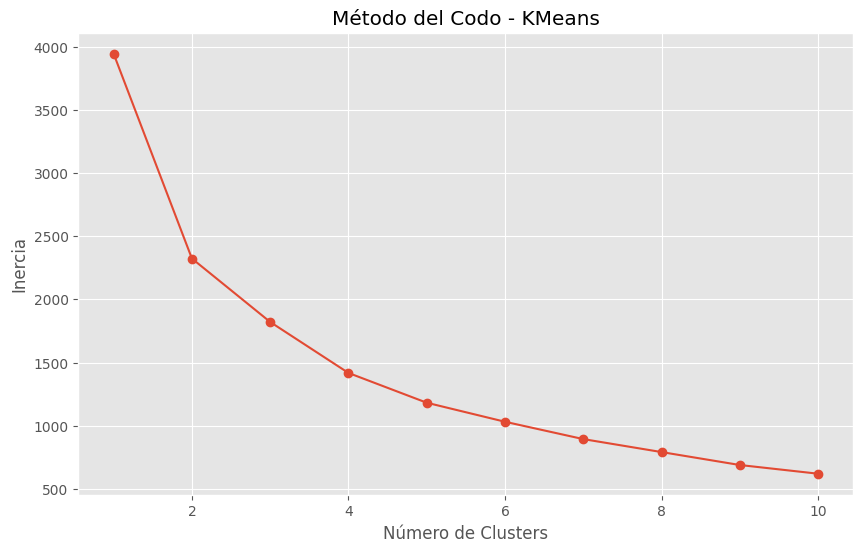

In [30]:
# =========================================================
# 33. GRÁFICA ELBOW METHOD
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    range(1, 11),
    inercia,
    marker='o'
)

plt.title('Método del Codo - KMeans')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

In [31]:
# =========================================================
# 34. SILHOUETTE SCORE
# =========================================================

from sklearn.metrics import silhouette_score

silhouette_scores = []

# ---------------------------------------------------------
# Evaluar diferentes clusters
# ---------------------------------------------------------

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_pca_final
    )

    score = silhouette_score(
        X_pca_final,
        labels
    )

    silhouette_scores.append(score)

    print(f'K={k} -> Silhouette Score: {score:.4f}')

K=2 -> Silhouette Score: 0.4202
K=3 -> Silhouette Score: 0.3620
K=4 -> Silhouette Score: 0.3741
K=5 -> Silhouette Score: 0.3992
K=6 -> Silhouette Score: 0.4107
K=7 -> Silhouette Score: 0.3807
K=8 -> Silhouette Score: 0.3674
K=9 -> Silhouette Score: 0.3783
K=10 -> Silhouette Score: 0.3816


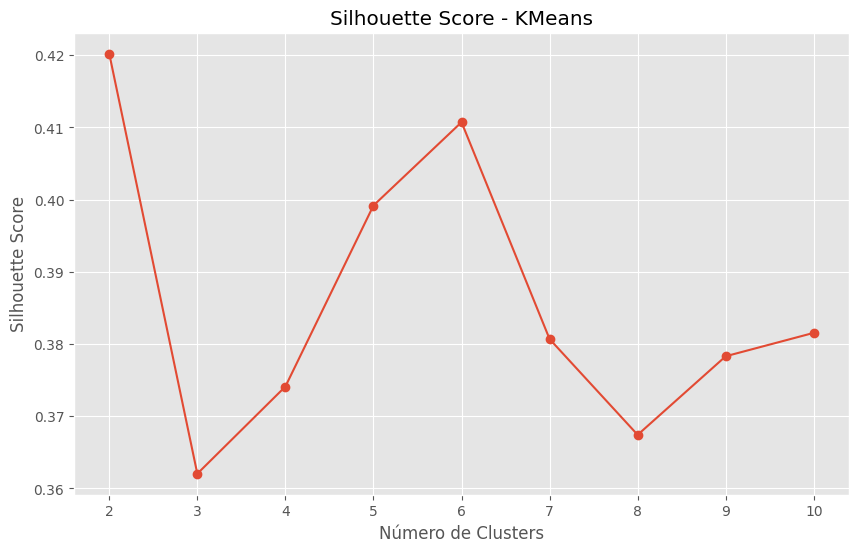

In [32]:
# =========================================================
# 35. GRÁFICA SILHOUETTE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score - KMeans')
plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show() 

In [33]:
# =========================================================
# 36. KMEANS FINAL
# =========================================================

from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# ---------------------------------------------------------
# Asignar clusters
# ---------------------------------------------------------

clusters = kmeans_final.fit_predict(
    X_pca_final
)

# ---------------------------------------------------------
# Agregar clusters al dataframe
# ---------------------------------------------------------

df_cluster_anual['CLUSTER'] = clusters

print(df_cluster_anual['CLUSTER'].value_counts())

CLUSTER
2    520
3    401
0    208
1    186
Name: count, dtype: int64


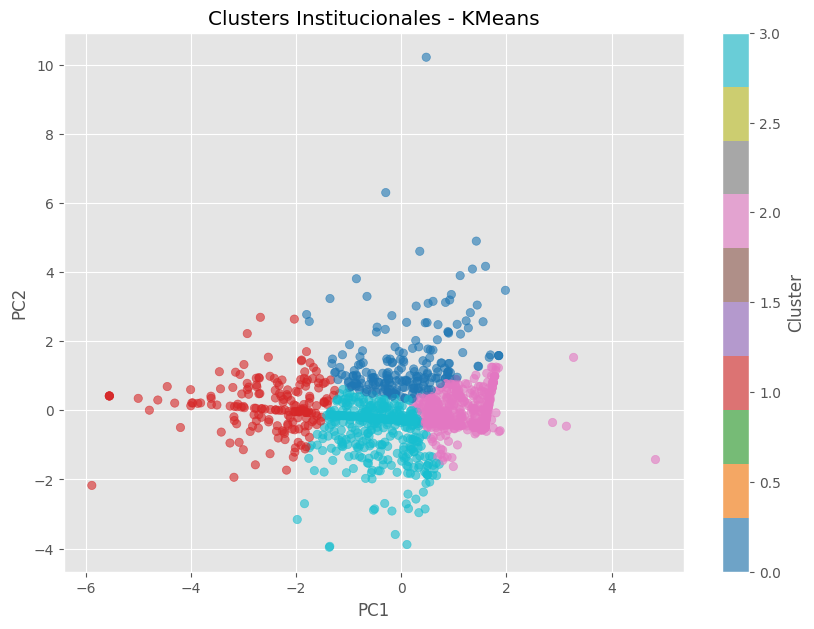

In [34]:
# =========================================================
# 37. VISUALIZACIÓN CLUSTERS
# =========================================================

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    c=df_cluster_anual['CLUSTER'],
    cmap='tab10',
    alpha=0.6
)

plt.title('Clusters Institucionales - KMeans')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

In [35]:
# =========================================================
# 38. PERFILAMIENTO CLUSTERS
# =========================================================

cluster_profile = df_cluster_anual.groupby(
    'CLUSTER'
)[features_cluster].mean()

print(cluster_profile)

         IND_EJECUCION  IND_COMPROMISO  VAR_EJECUCION
CLUSTER                                              
0            75.296234       76.386687      16.107740
1            46.872678       38.118005       1.090243
2            93.593244       94.007132       2.940819
3            71.993950       73.166273      -3.621109


In [36]:
# =========================================================
# 39. RENOMBRAR CLUSTERS
# =========================================================

cluster_names = {
    0: 'Desempeño en crecimiento',
    1: 'Bajo desempeño financiero',
    2: 'Alto desempeño financiero',
    3: 'Desempeño estable'
}

df_cluster_anual['NOMBRE_CLUSTER'] = df_cluster_anual[
    'CLUSTER'
].map(cluster_names)

print(
    df_cluster_anual[
        ['CLUSTER', 'NOMBRE_CLUSTER']
    ].head()
)

   CLUSTER             NOMBRE_CLUSTER
0        1  Bajo desempeño financiero
1        3          Desempeño estable
2        3          Desempeño estable
3        0   Desempeño en crecimiento
4        3          Desempeño estable


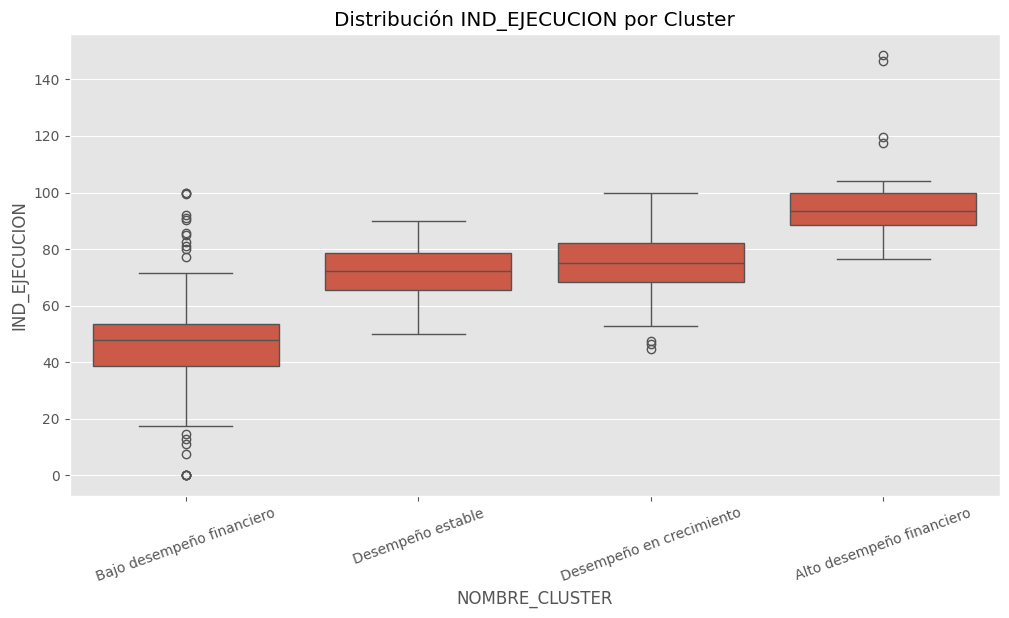

In [38]:
# =========================================================
# 40. BOXPLOT IND_EJECUCION
# =========================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_cluster_anual,
    x='NOMBRE_CLUSTER',
    y='IND_EJECUCION'
)

plt.xticks(rotation=20)

plt.title(
    'Distribución IND_EJECUCION por Cluster'
)

plt.show()

In [39]:
df_cluster_anual.groupby("CLUSTER").agg({
    "IND_EJECUCION":["mean","median"],
    "IND_COMPROMISO":["mean","median"],
    "VAR_EJECUCION":["mean","median"]
})

IND_EJECUCION            IND_COMPROMISO            VAR_EJECUCION  \
                 mean     median           mean     median          mean   
CLUSTER                                                                    
0           75.296234  75.184931      76.386687  76.368318     16.107740   
1           46.872678  47.924744      38.118005  45.696538      1.090243   
2           93.593244  93.305833      94.007132  93.872426      2.940819   
3           71.993950  72.157538      73.166273  72.678182     -3.621109   

                    
            median  
CLUSTER             
0        12.500000  
1         0.000000  
2         1.130000  
3        -0.102273

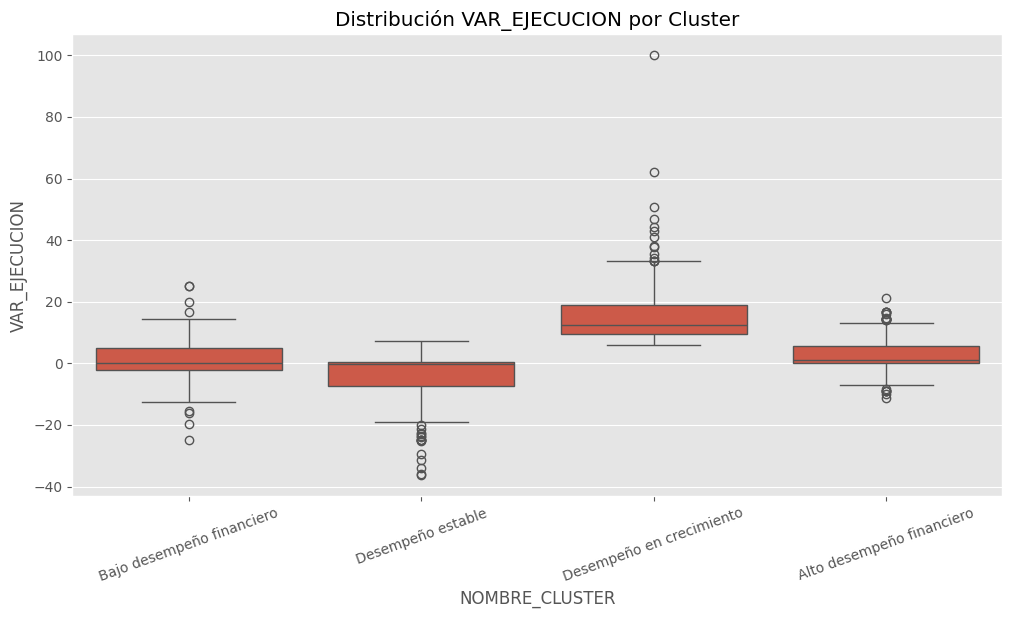

In [40]:
# =========================================================
# 41. BOXPLOT VAR_EJECUCION
# =========================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_cluster_anual,
    x='NOMBRE_CLUSTER',
    y='VAR_EJECUCION'
)

plt.xticks(rotation=20)
plt.title(
    'Distribución VAR_EJECUCION por Cluster'
)
plt.show()

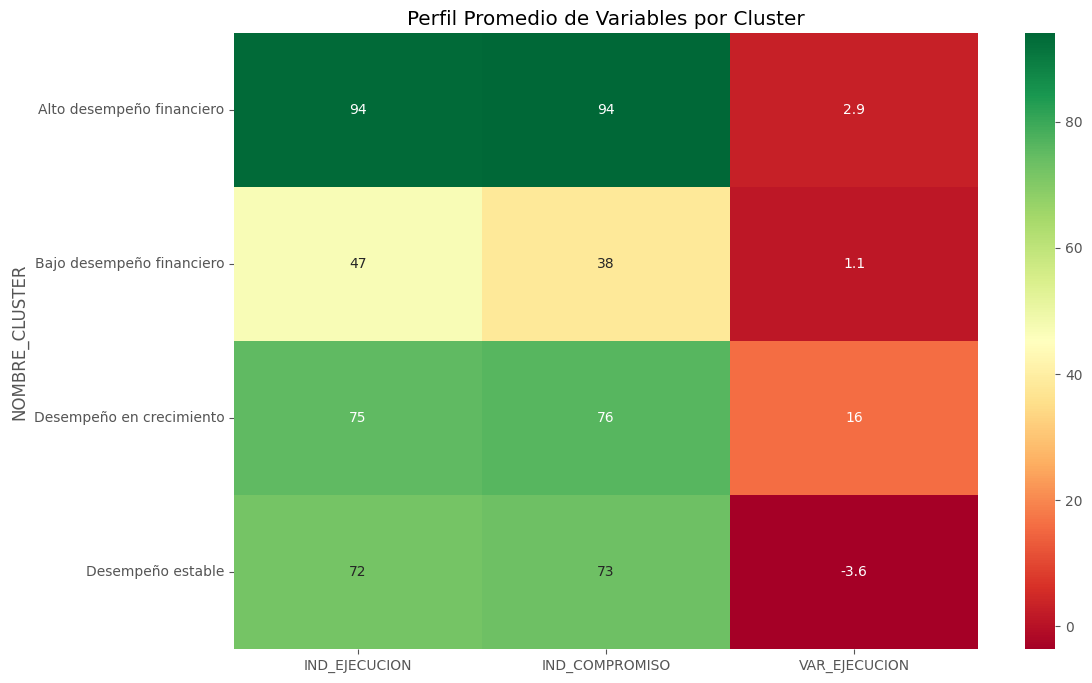

In [41]:
# =========================================================
# 42. HEATMAP CLUSTERS
# =========================================================

cluster_profile = df_cluster_anual.groupby(
    'NOMBRE_CLUSTER'
)[features_cluster].mean()

plt.figure(figsize=(12,8))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='RdYlGn'
)

plt.title(
    'Perfil Promedio de Variables por Cluster'
)

plt.show()

### Exportar dataset formato .json

In [42]:
orient='records'

In [43]:
# =========================================================
# EXPORTAR DATASET CLUSTERING JSON
# =========================================================

df_cluster_anual.to_json(
    'dataset_clustering_final.json',
    orient='records',
    force_ascii=False,
    indent=4
)

In [44]:
# =========================================================
# EXPORTAR PCA JSON
# =========================================================

df_pca.to_json(
    'dataset_pca.json',
    orient='records',
    force_ascii=False
)

print('Dataset PCA JSON exportado')

Dataset PCA JSON exportado


In [45]:
# =========================================================
# EXPORTAR PERFIL CLUSTERS JSON
# =========================================================

cluster_profile.reset_index().to_json(
    'perfil_clusters.json',
    orient='records',
    force_ascii=False
)

print('Perfil clusters JSON exportado')

Perfil clusters JSON exportado


In [46]:
#=========================================================
# EXPORTAR ALERTAS JSON
# =========================================================

dataset_alertas.to_json(
    'dataset_alertas_final.json',
    orient='records',
    force_ascii=False
)

df_predicciones.to_json(
    'dataset_predicciones_rf.json',
    orient='records',
    force_ascii=False
)

print('Dataset alertas JSON exportado')

Dataset alertas JSON exportado


### Exportar dataset a formato .csv

In [47]:
# =========================================================
# EXPORTAR CLUSTERING CSV
# =========================================================

df_cluster_anual.to_csv(
    'dataset_clustering_final.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Dataset clustering CSV exportado')

Dataset clustering CSV exportado


In [48]:
# =========================================================
# EXPORTAR PCA CSV
# =========================================================

df_pca.to_csv(
    'dataset_pca.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Dataset PCA CSV exportado')

Dataset PCA CSV exportado


In [49]:
# =========================================================
# EXPORTAR PERFIL CLUSTERS CSV
# =========================================================

cluster_profile.reset_index().to_csv(
    'perfil_clusters.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Perfil clusters CSV exportado')

Perfil clusters CSV exportado


In [50]:
# =========================================================
# EXPORTAR ALERTAS CSV
# =========================================================

dataset_alertas.to_csv(
    'dataset_alertas_final.csv',
    index=False,
    encoding='utf-8-sig'
)

df_predicciones.to_csv(
    'dataset_predicciones_rf.csv',
    index=False,
    encoding='utf-8-sig'
)

report_model1 = classification_report(
    y_test_model1,
    y_pred_model1,
    output_dict=True
)

df_metricas_model1 = pd.DataFrame(report_model1).transpose()

df_metricas_model1.to_csv(
    'metricas_random_forest_modelo1.csv',
    encoding='utf-8-sig'
)

pd.DataFrame(matriz_model1).to_csv(
    'matriz_confusion_modelo1.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Dataset alertas CSV exportado')

Dataset alertas CSV exportado


### Variables de Importancias

In [51]:
# =========================================================
# 48. EXPORTAR IMPORTANCIA VARIABLES
# =========================================================

importance.to_csv(
    'importance_variables_rf.csv',
    index=False,
    encoding='utf-8-sig'
)

importance.to_json(
    'importance_variables_rf.json',
    orient='records',
    force_ascii=False,
    indent=4
)

print('Importancia de variables exportada')


# =========================================================
# 49. EXPORTAR MÉTRICAS MODELO
# =========================================================

from sklearn.metrics import classification_report
import pandas as pd

# ---------------------------------------------------------
# Convertir classification_report a DataFrame
# ---------------------------------------------------------

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

# ---------------------------------------------------------
# Exportar CSV
# ---------------------------------------------------------

df_report.to_csv(
    'metricas_random_forest.csv',
    encoding='utf-8-sig'
)

# ---------------------------------------------------------
# Exportar JSON
# ---------------------------------------------------------

df_report.reset_index().to_json(
    'metricas_random_forest.json',
    orient='records',
    force_ascii=False,
    indent=4
)

print('Métricas Random Forest exportadas')


# =========================================================
# 50. EXPORTAR MATRIZ DE CONFUSIÓN
# =========================================================

from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(
    y_test,
    y_pred
)

df_matriz = pd.DataFrame(matriz)

# ---------------------------------------------------------
# CSV
# ---------------------------------------------------------

df_matriz.to_csv(
    'matriz_confusion.csv',
    index=False,
    encoding='utf-8-sig'
)

# ---------------------------------------------------------
# JSON
# ---------------------------------------------------------

df_matriz.to_json(
    'matriz_confusion.json',
    orient='records',
    force_ascii=False,
    indent=4
)

print('Matriz de confusión exportada')


# =========================================================
# 51. EXPORTAR SILHOUETTE SCORES
# =========================================================

df_silhouette = pd.DataFrame({
    'K': list(range(2,11)),
    'Silhouette_Score': silhouette_scores
})

# ---------------------------------------------------------
# CSV
# ---------------------------------------------------------

df_silhouette.to_csv(
    'silhouette_scores.csv',
    index=False,
    encoding='utf-8-sig'
)

# ---------------------------------------------------------
# JSON
# ---------------------------------------------------------

df_silhouette.to_json(
    'silhouette_scores.json',
    orient='records',
    force_ascii=False,
    indent=4
)

print('Silhouette scores exportados')

Importancia de variables exportada
Métricas Random Forest exportadas
Matriz de confusión exportada
Silhouette scores exportados
